In [1]:
import pandas as pd
import re
import json

In [2]:
# Specify the file name
file_name = "data"  # Replace with your file name

# Read the content of the file
with open(file_name, "r") as file:
    data = file.read()


# Pattern to match ${A..} and ${B..} blocks
pattern = r"\$\{([AB]\d+:[^}]+)\}"

# Extract matches using regex
matches = re.findall(pattern, data)

# Process and categorize the matches
data_blocks = {"A": [], "B": []}
for match in matches:
    if match.startswith("A"):
        data_blocks["A"].append(match)
    elif match.startswith("B"):
        data_blocks["B"].append(match)

# Function to parse individual entries (e.g., A0:0:7:86)
def parse_entry(entry):
    parts = entry.split(":")
    # Clean and convert values
    clean = lambda x: int(x.replace("‑", "-").replace("−", "-"))  # Replace non-standard hyphens
    if len(parts) == 4:
        key, start, length, value = parts
        return {"Encoder1": key[1:], "Encoder2": clean(start), "Voltage": clean(length), "phi": clean(value)}
    elif len(parts) == 3:
        key, start, value = parts
        return {"phi":key[1:], "phi_dot": clean(start), "Servo": clean(value)}
    else:
        return {"raw_entry": entry}  # Fallback for unexpected formats

# Parse data for A and B blocks
parsed_data = {"A": [parse_entry(entry) for entry in data_blocks["A"]],
               "B": [parse_entry(entry) for entry in data_blocks["B"]]}

# Example: Output the processed data
print("Parsed A data:")
for item in parsed_data["A"]:
    print(item)

print("\nParsed B data:")
for item in parsed_data["B"]:
    print(item)

# Optionally, save to a file
with open("parsed_data.json", "w") as f:
    import json
    json.dump(parsed_data, f, indent=4)

# Further processing can be added as needed


Parsed A data:
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}

In [6]:
# Load the JSON file
json_file = "parsed_data.json"  # Ensure this is the correct path to your JSON file

with open(json_file, "r") as f:
    data = json.load(f)

# Convert the "A" and "B" blocks to pandas DataFrames
df_a = pd.DataFrame(data["A"], columns=["Encoder1", "Encoder2", "Voltage", "phi"], dtype=float)
df_b = pd.DataFrame(data["B"], columns=["phi", "phi_dot", "Servo"], dtype=float)

# Display the DataFrames
print("DataFrame for A Block:")
print(df_a)

print("\nDataFrame for B Block:")
print(df_b)

# Save as CSV for further analysis if needed
df_a.to_csv("parsed_A_data.csv", index=False)
df_b.to_csv("parsed_B_data.csv", index=False)

DataFrame for A Block:
     Encoder1  Encoder2  Voltage   phi
0         0.0       0.0      7.0  86.0
1         0.0       0.0      7.0  86.0
2         0.0       0.0      7.0  86.0
3         0.0       0.0      6.0  86.0
4         0.0       0.0      6.0  86.0
..        ...       ...      ...   ...
829       0.0       0.0      0.0  23.0
830       0.0       0.0      0.0  23.0
831       0.0       0.0      0.0  25.0
832       0.0       0.0      0.0  22.0
833       0.0       0.0      0.0  21.0

[834 rows x 4 columns]

DataFrame for B Block:
      phi  phi_dot  Servo
0    86.0      0.0  751.0
1    86.0      0.0  752.0
2    86.0      1.0  751.0
3    86.0      0.0  751.0
4    86.0      0.0  751.0
..    ...      ...    ...
574  21.0     51.0  631.0
575  25.0      9.0  631.0
576  24.0     20.0  631.0
577  23.0    -14.0  631.0
578  22.0      1.0  631.0

[579 rows x 3 columns]


In [7]:
df_a_non_stationary = df_a[df_a['Encoder1'] != 0]
df_a_non_stationary

,Encoder1,Encoder2,Voltage,phi
26,44.0,44.0,20.0,-1.0
27,46.0,46.0,18.0,-4.0
28,47.0,47.0,18.0,-2.0
29,44.0,44.0,18.0,-2.0
30,47.0,47.0,20.0,-2.0
...,...,...,...,...
815,43.0,43.0,10.0,0.0
816,45.0,45.0,10.0,-1.0
817,52.0,52.0,10.0,-31.0
818,48.0,48.0,10.0,-35.0


Servo
751.0    52
697.0    25
705.0    22
703.0    20
702.0    18
         ..
733.0     1
667.0     1
680.0     1
723.0     1
681.0     1
Name: count, Length: 89, dtype: int64

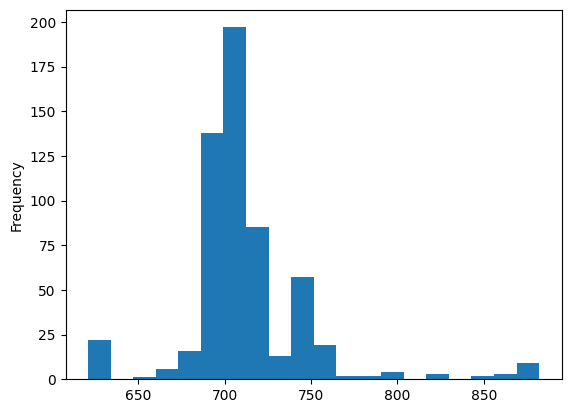

In [8]:
# df_b[df_b['Servo'] != 751]
df_b['Servo'].plot.hist(bins=20)
df_b['Servo'].value_counts()


In [9]:
# df_b[df_b['Servo'] != 751]
df_b[df_b['Servo'] <= 650]

,phi,phi_dot,Servo
54,5.0,-99.0,621.0
55,17.0,-33.0,621.0
56,26.0,-3.0,621.0
57,31.0,-5.0,621.0
58,32.0,7.0,621.0
59,28.0,-11.0,621.0
60,25.0,17.0,621.0
61,19.0,-1.0,621.0
62,14.0,7.0,621.0
63,11.0,49.0,621.0


In [10]:
df_b[df_b['Servo'] >=740]


,phi,phi_dot,Servo
0,86.0,0.0,751.0
1,86.0,0.0,752.0
2,86.0,1.0,751.0
3,86.0,0.0,751.0
4,86.0,0.0,751.0
...,...,...,...
139,43.0,120.0,882.0
140,49.0,20.0,882.0
141,49.0,-26.0,881.0
142,36.0,-161.0,882.0


In [17]:
# df_b[df_b['phi_dot']==0]

,phi,phi_dot,Servo
0,86.0,0.0,751.0
1,86.0,0.0,752.0
3,86.0,0.0,751.0
4,86.0,0.0,751.0
5,86.0,0.0,751.0
...,...,...,...
528,0.0,0.0,708.0
538,0.0,0.0,697.0
550,0.0,0.0,705.0
554,0.0,0.0,703.0


In [32]:
normalised_servo = df_b['Servo']-df_b['Servo'].mean()
normalised_servo /= df_b['Servo'].std()
# df_b['Servo'] = normalised_servo
minmax_normalised_servo = (df_b['Servo']-df_b['Servo'].min())/(df_b['Servo'].max()-df_b['Servo'].min())
df_b['Servo'] = minmax_normalised_servo
minmax_normalised


0      0.498084
1      0.501916
2      0.498084
3      0.498084
4      0.498084
         ...   
574    0.038314
575    0.038314
576    0.038314
577    0.038314
578    0.038314
Name: Servo, Length: 579, dtype: float64

In [33]:
df_b

,phi,phi_dot,Servo
0,86.0,0.0,0.498084
1,86.0,0.0,0.501916
2,86.0,1.0,0.498084
3,86.0,0.0,0.498084
4,86.0,0.0,0.498084
...,...,...,...
574,21.0,51.0,0.038314
575,25.0,9.0,0.038314
576,24.0,20.0,0.038314
577,23.0,-14.0,0.038314
